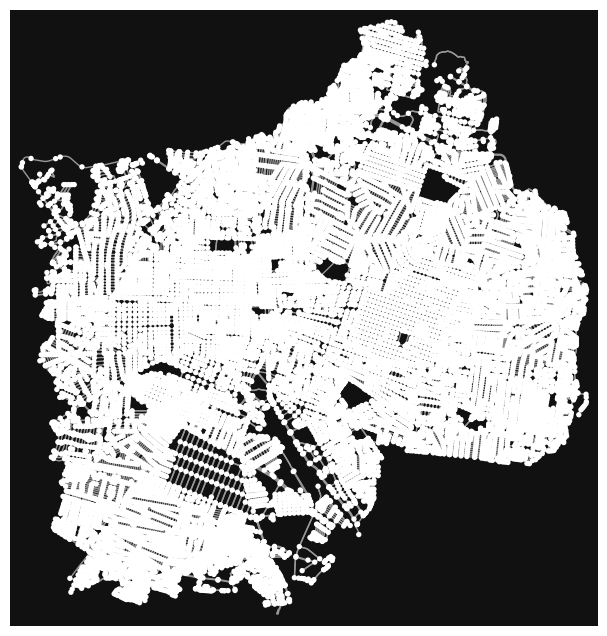

In [1]:
import osmnx as ox
import matplotlib.pyplot as plt

G = ox.graph_from_place("Guadalajara, Jalisco, Mexico", network_type="drive")
fig, ax = ox.plot_graph(G)
plt.show()


In [2]:
# Convertir el grafo a tablas de datos
nodes, edges = ox.graph_to_gdfs(G)

# Ver cuántos nodos e intersecciones hay
print(f"Intersecciones: {len(nodes)}")
print(f"Segmentos de calle: {len(edges)}")

# Ver las primeras filas de calles
edges[['name', 'length', 'highway']].head(10)


Intersecciones: 22276
Segmentos de calle: 50180


name      length      highway
u        v          key                                                      
28751344 1610958191 0                            NaN   22.824592    secondary
         28757777   0              Calle San Ignacio  168.215321     tertiary
28753224 1601906810 0    Calle Nudo de Cempoaltépetl   47.170569  residential
         1601906764 0    Calle Nudo de Cempoaltépetl   48.083655  residential
28757751 6133633659 0              Calle San Ignacio  129.726639     tertiary
         292038785  0              Calle San Ignacio   92.948758     tertiary
         292038837  0                 Calle Justicia   83.228391     tertiary
28757777 292038785  0              Calle San Ignacio   90.444544     tertiary
         1967782009 0               Calle Abundancia   90.049185     tertiary
         1211192891 0               Calle Abundancia  167.553845     tertiary

In [3]:
# ¿Qué tipos de vialidad existen y cuántos segmentos tiene cada uno?
edges['highway'].value_counts()


highway
residential                     37862
tertiary                         4996
secondary                        2420
living_street                    1793
primary                          1742
unclassified                      627
busway                            170
primary_link                      165
tertiary_link                      98
secondary_link                     83
trunk                              80
trunk_link                         43
motorway                           36
motorway_link                      36
[residential, living_street]       14
[living_street, residential]       14
[secondary, secondary_link]         1
Name: count, dtype: int64

In [4]:
# Convertir highway a string para manejar los casos con múltiples valores
edges['highway_str'] = edges['highway'].astype(str)
edges.groupby('highway_str')['length'].mean().round(1).sort_values(ascending=False)


highway_str
['secondary', 'secondary_link']     609.1
motorway                            480.1
busway                              215.6
trunk                               195.1
['living_street', 'residential']    148.0
['residential', 'living_street']    148.0
unclassified                        128.0
motorway_link                       117.8
primary                             102.1
secondary                            83.1
residential                          80.1
trunk_link                           72.5
tertiary                             70.6
living_street                        57.0
primary_link                         56.6
secondary_link                       47.3
tertiary_link                        45.9
Name: length, dtype: float64

## Análisis de red vial — Guadalajara, Jalisco

Este notebook analiza la estructura de la red vial de Guadalajara 
usando datos de OpenStreetMap obtenidos con osmnx.

**Preguntas que exploramos:**
- ¿Cuántos segmentos y nodos tiene la red?
- ¿Cómo se distribuye la red por tipo de vialidad?
- ¿Cuál es la longitud promedio de calle por jerarquía vial?

In [5]:
stats = ox.basic_stats(G)

for k, v in stats.items():
    print(f"{k}: {v}")
    

n: 22276
m: 50180
k_avg: 4.50529718082241
edge_length_total: 4046743.0400998206
edge_length_avg: 80.64454045635354
streets_per_node_avg: 3.2456904291614292
streets_per_node_counts: {0: 0, 1: 2101, 2: 39, 3: 10529, 4: 9509, 5: 89, 6: 9}
streets_per_node_proportions: {0: 0.0, 1: 0.09431675345663494, 2: 0.0017507631531693303, 3: 0.4726611599928174, 4: 0.42687196983300413, 5: 0.003995331298258215, 6: 0.0004040222661159993}
intersection_count: 20175
street_length_total: 2999232.011908676
street_segment_count: 35966
street_length_avg: 83.39075826916188
circuity_avg: 1.014231249956659
self_loop_proportion: 0.0009453372629705833


## Red vial de Guadalajara — Estadísticas básicas

La red vial del municipio de Guadalajara contiene **22,277 nodos** 
(intersecciones) y **50,180 aristas** (segmentos de calle), con una 
longitud total de red de aproximadamente **3,000 km**.

La conectividad promedio es de **3.25 calles por intersección**, lo que 
refleja una trama predominantemente en cuadrícula: casi el 43% de los 
nodos tienen 4 conexiones (cruces de 4 vías), y el 47% tienen 3. 
Esto es característico de una ciudad con trama ortogonal heredada del 
período colonial, con interrupciones en zonas periféricas o de 
crecimiento irregular.

El índice de circuidad es de **1.014**, prácticamente 1.0, lo que 
significa que las rutas reales son solo un 1.4% más largas que la 
distancia en línea recta. Una red muy eficiente geométricamente.

In [6]:
import subprocess
subprocess.run(["pip", "install", "scipy"])

CompletedProcess(args=['pip', 'install', 'scipy'], returncode=0)

In [7]:
import subprocess
subprocess.run(["pip", "install", "scikit-learn"])

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 16.7 MB/s  0:00:008.0 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [scikit-learn]━━━━━ 2/3 [scikit-learn]


CompletedProcess(args=['pip', 'install', 'scikit-learn'], returncode=0)

In [9]:
import osmnx as ox
import networkx as nx
import matplotlib.pyplot as plt

center_point = (20.6841647, -103.3406111)

G_walk = ox.graph_from_point(center_point, dist=2000, network_type="walk")
G_walk_proj = ox.project_graph(G_walk)

# Encontrar nodo más cercano manualmente — sin scikit-learn
nodes_gdf = ox.graph_to_gdfs(G_walk, edges=False)
lat, lon = center_point
distances = ((nodes_gdf['y'] - lat)**2 + (nodes_gdf['x'] - lon)**2)**0.5
center_node = distances.idxmin()

# Isócrona
subgraph = nx.ego_graph(G_walk_proj, center_node, radius=1200, distance='length')

print(f"Nodos alcanzables: {len(subgraph.nodes)}")

Nodos alcanzables: 1036


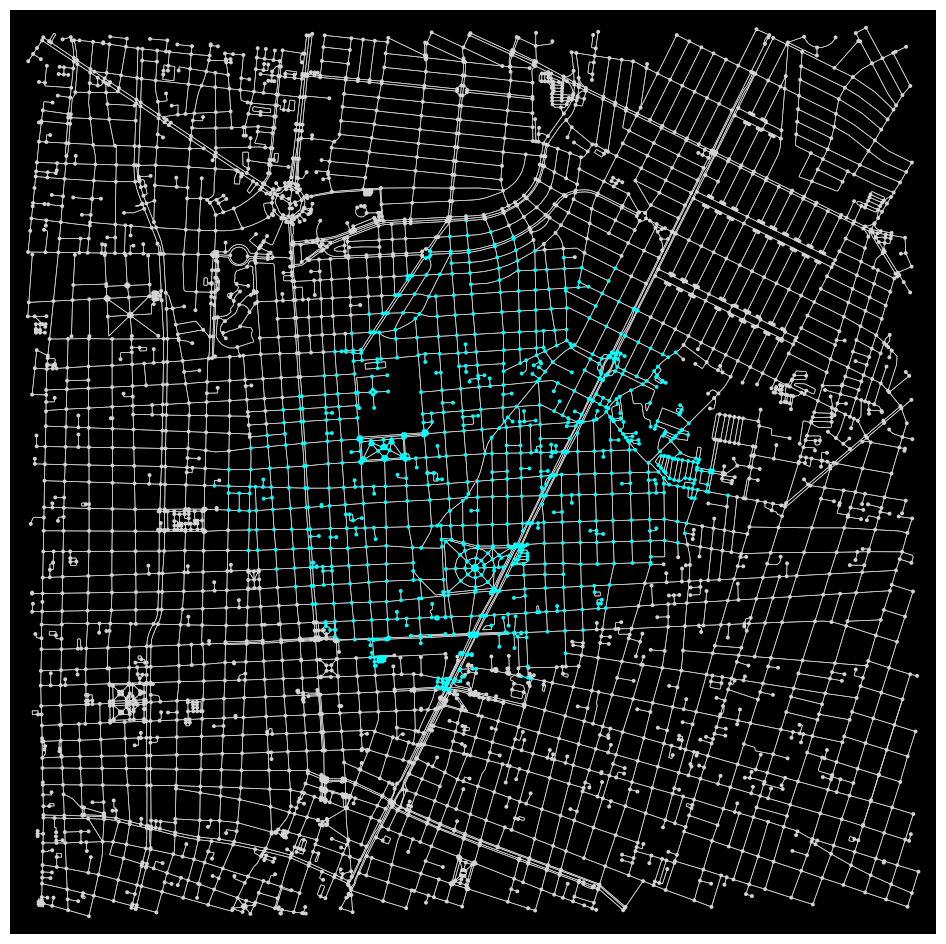

In [10]:
node_colors = []
for node in G_walk_proj.nodes():
    if node == center_node:
        node_colors.append('red')
    elif node in subgraph.nodes():
        node_colors.append('cyan')
    else:
        node_colors.append('lightgray')

fig, ax = ox.plot_graph(
    G_walk_proj,
    node_color=node_colors,
    node_size=8,
    edge_color='lightgray',
    edge_linewidth=0.5,
    bgcolor='black',
    figsize=(12, 12)
)

## Accesibilidad peatonal desde Plaza de la Liberación

La isócrona muestra los 1,036 nodos alcanzables caminando 15 minutos 
(~1,200m por red) desde Plaza de la Liberación, en el centro histórico 
de Guadalajara.

La forma irregular refleja la estructura real de la red peatonal: 
la trama ortogonal del centro histórico permite una expansión amplia 
hacia el norte y noroeste, mientras que las vialidades diagonales 
actúan como barreras que fragmentan la continuidad peatonal hacia 
el sureste.

Este análisis es la base del concepto de "ciudad de 15 minutos": 
no todos los puntos equidistantes en línea recta son igualmente 
accesibles — la morfología urbana define quién puede llegar a dónde.

In [13]:
# Descargar escuelas del área (OSM)
schools = ox.features_from_point(
    center_point, 
    tags={'amenity': 'school'}, 
    dist=2000
)

print(f"Total escuelas: {len(schools)}")

# Ver si hay columna de tipo de escuela
if 'school:type' in schools.columns:
    print(schools['school:type'].value_counts())

# Buscar primarias por nombre
primarias = schools[schools['name'].str.contains('Primaria|primaria', na=False)]
print(f"\nPrimarias encontradas por nombre: {len(primarias)}")
print(primarias[['name']].to_string())


Total escuelas: 186

Primarias encontradas por nombre: 1
                                           name
element id                                     
way     1376304936  Primaria Miguel Hidalgo #23


In [14]:
import subprocess
import os

# Descargar DENUE Jalisco (clave 14)
url = "https://www.inegi.org.mx/contenidos/masiva/denue/denue_14_csv.zip"
subprocess.run(["curl", "-L", "-o", "denue_jalisco.zip", url])

# Descomprimir
subprocess.run(["unzip", "-o", "denue_jalisco.zip", "-d", "denue_jalisco"])

# Ver qué archivos hay dentro
os.listdir("denue_jalisco")

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 37.0M  100 37.0M    0     0  2088k      0  0:00:18  0:00:18 --:--:-- 2129k


Archive:  denue_jalisco.zip
  inflating: denue_jalisco/diccionario_de_datos/denue_diccionario_de_datos.csv  
  inflating: denue_jalisco/conjunto_de_datos/denue_inegi_14_.csv  
  inflating: denue_jalisco/metadatos/metadatos_denue.txt  


['metadatos', 'diccionario_de_datos', 'conjunto_de_datos']

In [15]:
import pandas as pd

# Cargar DENUE Jalisco
denue = pd.read_csv("denue_jalisco/conjunto_de_datos/denue_inegi_14_.csv", 
                    encoding='latin-1', low_memory=False)

print(f"Total registros: {len(denue)}")
print(denue.columns.tolist())

Total registros: 399103
['id', 'clee', 'nom_estab', 'raz_social', 'codigo_act', 'nombre_act', 'per_ocu', 'tipo_vial', 'nom_vial', 'tipo_v_e_1', 'nom_v_e_1', 'tipo_v_e_2', 'nom_v_e_2', 'tipo_v_e_3', 'nom_v_e_3', 'numero_ext', 'letra_ext', 'edificio', 'edificio_e', 'numero_int', 'letra_int', 'tipo_asent', 'nomb_asent', 'tipoCenCom', 'nom_CenCom', 'num_local', 'cod_postal', 'cve_ent', 'entidad', 'cve_mun', 'municipio', 'cve_loc', 'localidad', 'ageb', 'manzana', 'telefono', 'correoelec', 'www', 'tipoUniEco', 'latitud', 'longitud', 'fecha_alta']


In [16]:
# Filtrar escuelas primarias
primarias = denue[denue['codigo_act'].isin([611121, 611122])]

print(f"Escuelas primarias en Jalisco: {len(primarias)}")
print(primarias[['nom_estab', 'municipio', 'latitud', 'longitud']].head(10))

Escuelas primarias en Jalisco: 2748
                                        nom_estab              municipio  \
246825  1238 EPIGMENIO GONZALEZ URBANA 14EPR1384A                 Tonalá   
246826                15 DE MAYO TURNO VESPERTINO  San Pedro Tlaquepaque   
246829                                  5 DE MAYO  Tepatitlán de Morelos   
246830                          5 DE MAYO DE 1862  Tepatitlán de Morelos   
247013                    ACADEMIA PIEDRA ANGULAR                Zapopan   
247054                        ADOLFO LOPEZ MATEOS          Jalostotitlán   
247055               ADOLFO LOPEZ MATEOS PRIMARIA  San Pedro Tlaquepaque   
247056       ADOLFO LOPEZ MATEOS TURNO VESPERTINO                Arandas   
247059                         AGUSTIN DE LA ROSA  Tepatitlán de Morelos   
247060                              AGUSTIN YAÑEZ  San Pedro Tlaquepaque   

          latitud    longitud  
246825  20.665027 -103.207426  
246826  20.607032 -103.351230  
246829  20.820672 -102.767393  

In [17]:
import geopandas as gpd

zm_gdl = ['Guadalajara', 'Zapopan', 'San Pedro Tlaquepaque', 
          'Tonalá', 'Tlajomulco de Zúñiga', 'El Salto', 
          'Juanacatlán', 'Ixtlahuacán de los Membrillos']

primarias_zm = primarias[primarias['municipio'].isin(zm_gdl)].copy()
print(f"Primarias en ZM Guadalajara: {len(primarias_zm)}")

# Convertir a GeoDataFrame
primarias_gdf = gpd.GeoDataFrame(
    primarias_zm,
    geometry=gpd.points_from_xy(primarias_zm['longitud'], primarias_zm['latitud']),
    crs='EPSG:4326'
)

print(primarias_gdf[['nom_estab', 'municipio', 'geometry']].head(5))

Primarias en ZM Guadalajara: 1485
                                        nom_estab              municipio  \
246825  1238 EPIGMENIO GONZALEZ URBANA 14EPR1384A                 Tonalá   
246826                15 DE MAYO TURNO VESPERTINO  San Pedro Tlaquepaque   
247013                    ACADEMIA PIEDRA ANGULAR                Zapopan   
247055               ADOLFO LOPEZ MATEOS PRIMARIA  San Pedro Tlaquepaque   
247060                              AGUSTIN YAÑEZ  San Pedro Tlaquepaque   

                           geometry  
246825  POINT (-103.20743 20.66503)  
246826  POINT (-103.35123 20.60703)  
247013   POINT (-103.45117 20.6064)  
247055  POINT (-103.34015 20.59068)  
247060   POINT (-103.3169 20.60096)  


In [18]:
# Red peatonal de toda la ZM de Guadalajara
# Advertencia: descarga grande — puede tardar 5-10 minutos
G_zm = ox.graph_from_place(
    ["Guadalajara, Jalisco, Mexico",
     "Zapopan, Jalisco, Mexico", 
     "San Pedro Tlaquepaque, Jalisco, Mexico",
     "Tonalá, Jalisco, Mexico",
     "Tlajomulco de Zúñiga, Jalisco, Mexico",
     "El Salto, Jalisco, Mexico"],
    network_type="walk",
    retain_all=False
)

G_zm_proj = ox.project_graph(G_zm)

nodes_zm, _ = ox.graph_to_gdfs(G_zm_proj)
print(f"Nodos en la red ZM: {len(nodes_zm)}")

Nodos en la red ZM: 166528


In [19]:
import numpy as np
from scipy.spatial import cKDTree

# Proyectar escuelas al mismo CRS que la red
primarias_proj = primarias_gdf.to_crs(nodes_zm.crs)

# Coordenadas de nodos de la red
node_coords = np.array([[geom.x, geom.y] for geom in nodes_zm.geometry])
node_ids = nodes_zm.index.tolist()

# Árbol espacial para búsqueda eficiente
tree = cKDTree(node_coords)

# Encontrar nodo más cercano para cada escuela
school_coords = np.array([[geom.x, geom.y] for geom in primarias_proj.geometry])
_, indices = tree.query(school_coords)
school_nodes = [node_ids[i] for i in indices]

print(f"Nodos de escuelas encontrados: {len(school_nodes)}")

Nodos de escuelas encontrados: 1485


In [20]:
# Multi-source Dijkstra: distancia desde cualquier escuela a cada nodo
# cutoff=1200 → solo calcula hasta 1,200 metros (15 min caminando)
distances = nx.multi_source_dijkstra_path_length(
    G_zm_proj, 
    sources=school_nodes, 
    cutoff=1200, 
    weight='length'
)

reachable_nodes = set(distances.keys())
print(f"Nodos dentro de 15 min de alguna primaria: {len(reachable_nodes)}")
print(f"Total nodos ZM: {len(nodes_zm)}")
print(f"Cobertura: {len(reachable_nodes)/len(nodes_zm)*100:.1f}%")

Nodos dentro de 15 min de alguna primaria: 125079
Total nodos ZM: 166528
Cobertura: 75.1%


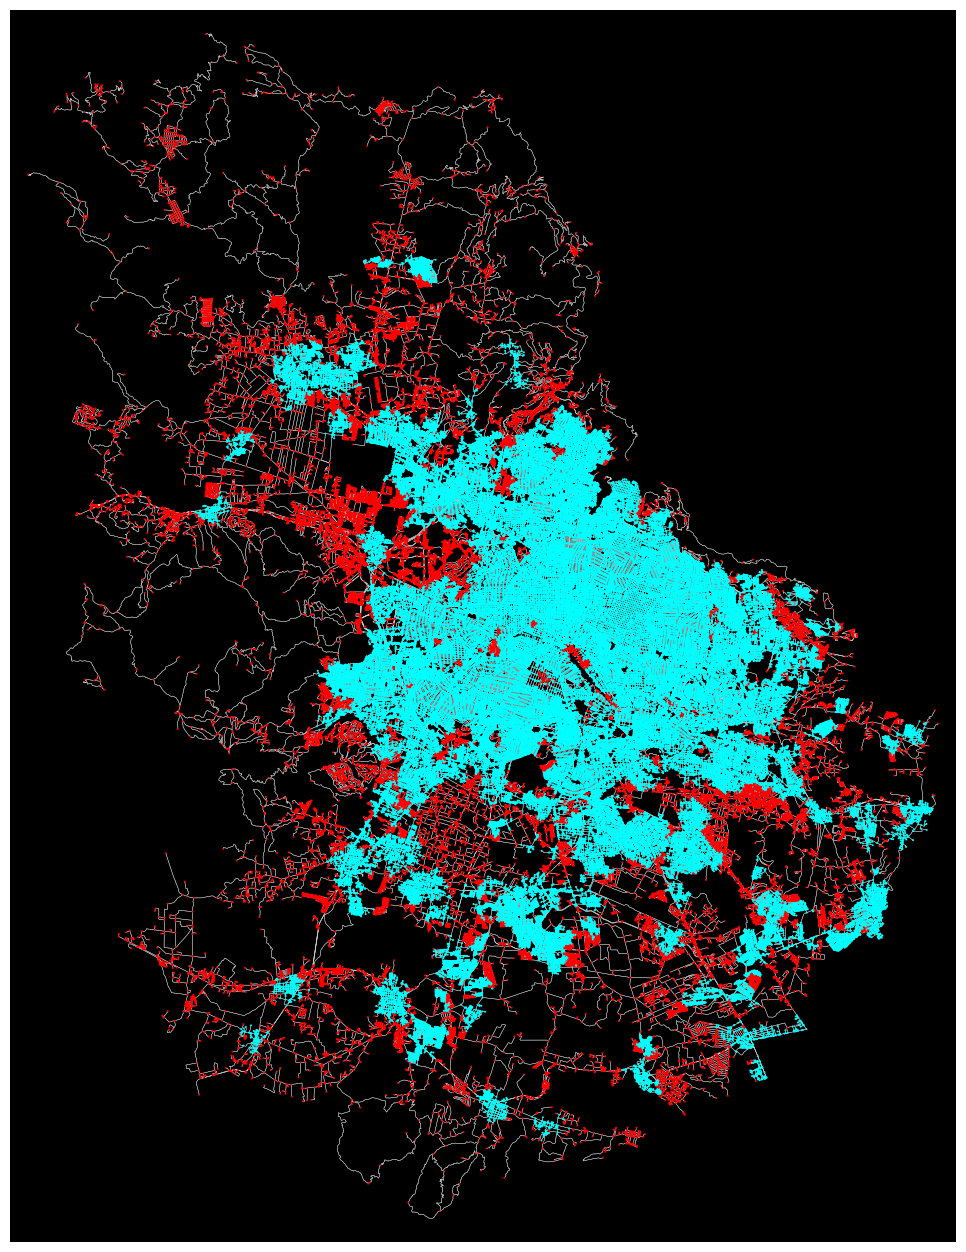

In [21]:
# Colorear nodos según cobertura
node_colors = [
    'cyan' if node in reachable_nodes else 'red' 
    for node in G_zm_proj.nodes()
]

fig, ax = ox.plot_graph(
    G_zm_proj,
    node_color=node_colors,
    node_size=2,
    edge_color='lightgray',
    edge_linewidth=0.3,
    bgcolor='black',
    figsize=(16, 16)
)

## Cobertura de escuelas primarias — ZM Guadalajara

**Fuente:** INEGI DENUE 2025 (1,485 escuelas primarias) + OpenStreetMap

El análisis calcula la zona accesible caminando 15 minutos (1,200m por 
red peatonal) desde cada escuela primaria en la Zona Metropolitana de 
Guadalajara, usando Multi-Source Dijkstra sobre una red de 166,528 nodos.

**Resultado:** El 75.1% de los nodos de la red están dentro de 15 minutos 
caminando de alguna primaria. El 24.9% restante concentrado en la 
periferia norte (Zapopan), sur (Tlajomulco) y oriente (Tonalá no 
tiene cobertura peatonal adecuada.

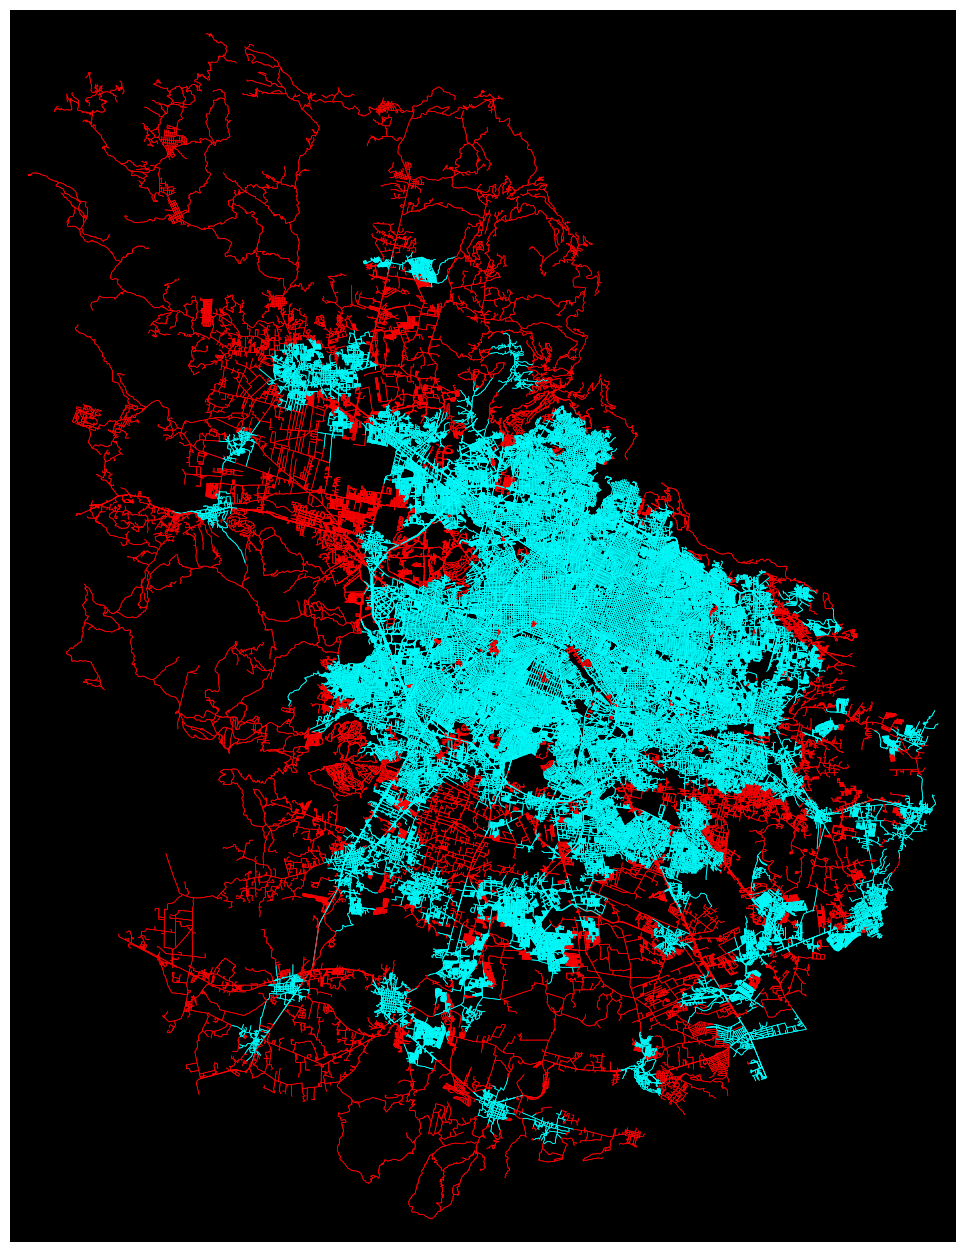

In [29]:
edge_colors = []
for u, v, data in G_zm_proj.edges(data=True):
    if u in reachable_nodes or v in reachable_nodes:
        edge_colors.append('cyan')
    else:
        edge_colors.append('red')

fig, ax = ox.plot_graph(
    G_zm_proj,
    node_size=0,          # ocultar nodos
    edge_color=edge_colors,
    edge_linewidth=0.5,
    bgcolor='black',
    figsize=(16, 16)
)

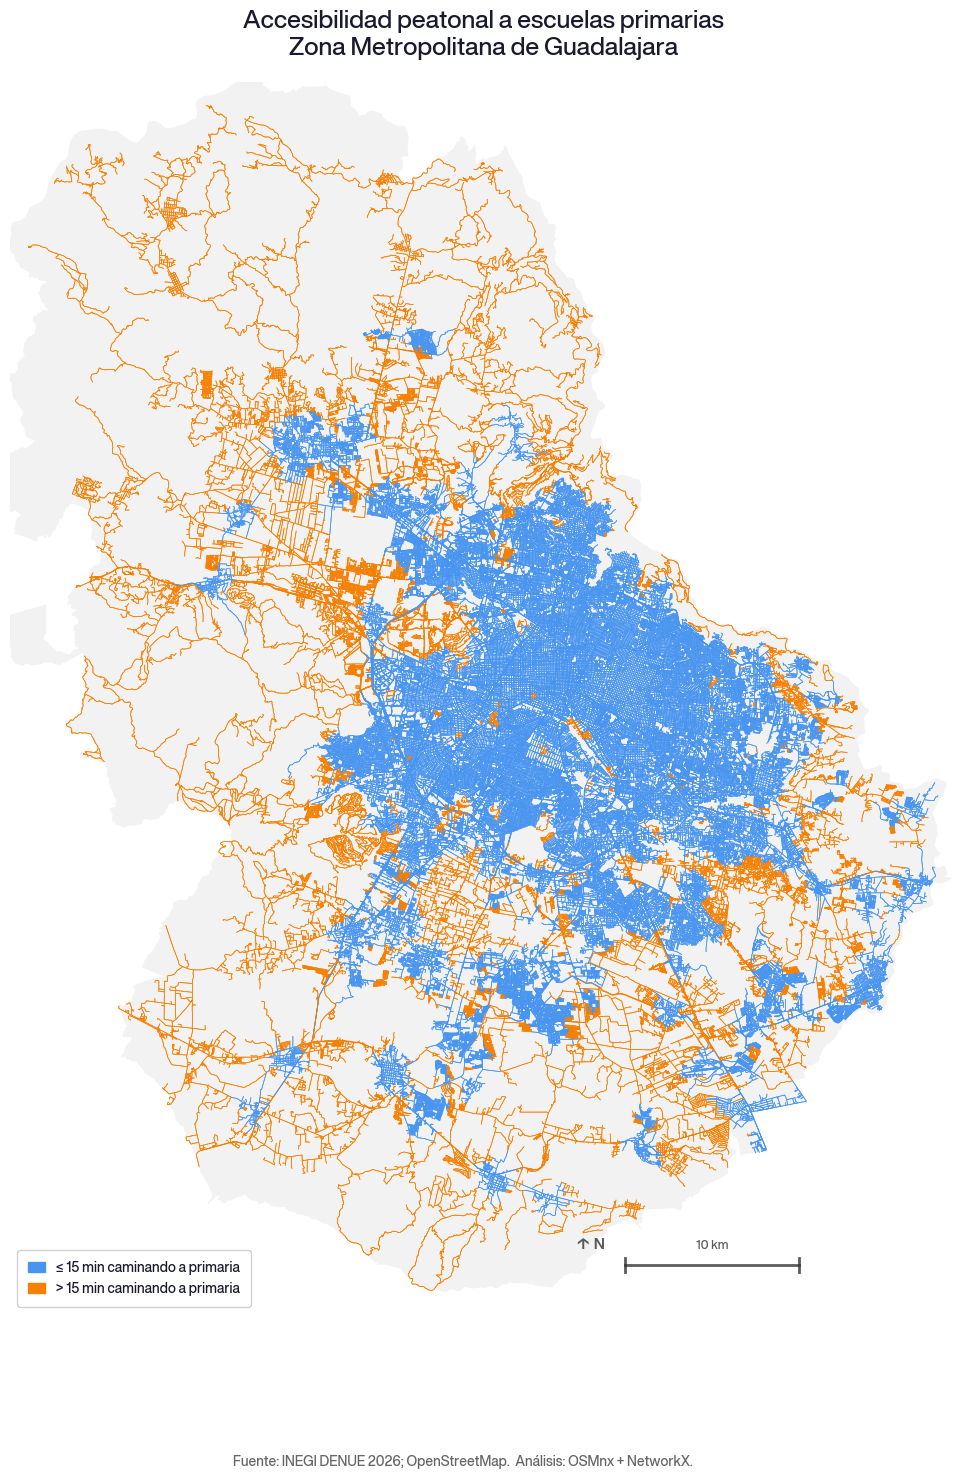

Guardado.


In [34]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib as mpl

mpl.rcParams['font.family'] = 'Helvetica Now Display'

BG = '#ffffff'
COVERED = '#4895ef'
GAP = '#f77f00'

edge_colors_v2 = [
    COVERED if (u in reachable_nodes or v in reachable_nodes) else GAP
    for u, v, _ in G_zm_proj.edges(data=True)
]

zm_places = [
    "Guadalajara, Jalisco, Mexico",
    "Zapopan, Jalisco, Mexico",
    "San Pedro Tlaquepaque, Jalisco, Mexico",
    "Tonalá, Jalisco, Mexico",
    "Tlajomulco de Zúñiga, Jalisco, Mexico",
    "El Salto, Jalisco, Mexico"
]
zm_gdf = ox.geocode_to_gdf(zm_places).to_crs(nodes_zm.crs)

fig, ax = ox.plot_graph(
    G_zm_proj,
    node_size=0,
    edge_color=edge_colors_v2,
    edge_linewidth=0.5,
    bgcolor=BG,
    figsize=(16, 16),
    show=False,
    close=False
)

zm_gdf.plot(ax=ax, color='#e0e0e0', alpha=0.4, zorder=0)

ax.set_title(
    "Accesibilidad peatonal a escuelas primarias\nZona Metropolitana de Guadalajara",
    color='#1a1a2e', fontsize=18, fontweight='medium', pad=20
)

ax.legend(
    handles=[
        mpatches.Patch(color=COVERED, label='≤ 15 min caminando a primaria'),
        mpatches.Patch(color=GAP, label='> 15 min caminando a primaria')
    ],
    loc='lower left', fontsize=10,
    facecolor='white', edgecolor='#cccccc',
    labelcolor='#1a1a2e', framealpha=0.9,
    borderpad=0.8, handlelength=1.2
)

xmin, xmax = ax.get_xlim()
ymin, ymax = ax.get_ylim()
sx = xmin + (xmax - xmin) * 0.65
sy = ymin + (ymax - ymin) * 0.04

ax.plot([sx, sx + 10000], [sy, sy], color='#333333', linewidth=2, alpha=0.8)
ax.plot([sx, sx], [sy-400, sy+400], color='#333333', linewidth=2, alpha=0.8)
ax.plot([sx+10000, sx+10000], [sy-400, sy+400], color='#333333', linewidth=2, alpha=0.8)
ax.text(sx + 5000, sy + 900, '10 km', color='#333333', fontsize=9, ha='center', alpha=0.8)
ax.text(sx - 2000, sy + 900, '↑ N', color='#333333', fontsize=11, ha='center', fontweight='bold', alpha=0.8)

fig.text(0.5, 0.015, 'Fuente: INEGI DENUE 2026; OpenStreetMap.  Análisis: OSMnx + NetworkX.', ha='center', color='#666666', fontsize=10)

plt.savefig('accesibilidad_primarias_zm_gdl_v2.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
print("Guardado.")